# 서비스 문제 정의

KPI 설정, 데이터를 분석하고 시각화하고 보고서를 작성하고 요약을 수행했다고 가정해보겠다. 이 과정을 통해서 도출된 보고서는 무엇이 일어났는가는 정확히 이야기 할 수 있지만 그것이 누구에게 왜 문제인가는 이야기 하지 않는다.

서비스 기획을 출발점인 문제 정의에 대해서 살펴보겠다.

## 문제 정의에서 문제란 무엇인가
매일 20분 걸리는 출근 시간이 어느 날 40분이 걸렸다. 길이 막힌다라는 문제를 느낀다. 이 길을 처음 가는 사람은 40분 걸리면 그냥 그런가 보다 한다. 같은 40분이라는 상황이 누구에게는 문제이고 누구에게는 문제가 아닐 수 있다. 기대하던 상태와 지금의 상태에서 차이가 발생하기 때문이다.

문제를 단순히 정의해보면 기대상태와 현재 상태의 차이 정도로 정리해 볼 수 있다. 기대 상태 이 정도면 괜찮아의 수준이고 현재상태는 실제로 관찰한 지금 시점의 상태를 의미한다. 차이가 없으면 문제가 없거나 적은거고 차이가 크면 문제가 크다고 볼 수 있다.

기대 상태를 누가 정하는가가 중요해진다. 관제 담당자가 기대하는 한 시간에 들어오는 배의 수와 선사가 기대하는 입항까지 걸리는 시간은 서로 다른 지표이지만 같은 목표를 두고 기대 수준이 달라진다.

서비스를 기획할 때 누구의 입장으로서 문제를 정의할 것인지를 명확히 하는 것이 권장된다.

- 차이 = 현재 상태 - 기대 상태
- 차이율 = 차이/기대상태 * 100

In [1]:
from typing import cast

import matplotlib.pyplot as plt

views = [
    {
        '누구': '관제 담당자',
        '지표': '시간당 최대 입항 척수',
        '기대': 11,
        '현재': 15,
        '클수록 나쁨': True
    },
    {
        '누구': '터미널 선석 담당자',
        '지표': '하루 컨테이너선 입항 척수',
        '기대': 39,
        '현재': 47,
        '클수록 나쁨': True
    },
    {
        '누구': '항만공사 운영 담당자',
        '지표': '하루 전체 입항 척수',
        '기대': 127,
        '현재': 189,
        '클수록 나쁨': False
    },
]

for v in views:
    gap = v['현재']- v['기대']
    gap_rate = gap/v['기대'] * 100

    is_problem = (gap>0) == v['클수록 나쁨']

    print(f"""
    {v['누구']}: {v['지표']} 차이 {gap} ({gap_rate:.1f}%) = {'문제' if is_problem else '문제아님'}
""".strip())


관제 담당자: 시간당 최대 입항 척수 차이 4 (36.4%) = 문제
터미널 선석 담당자: 하루 컨테이너선 입항 척수 차이 8 (20.5%) = 문제
항만공사 운영 담당자: 하루 전체 입항 척수 차이 62 (48.8%) = 문제아님


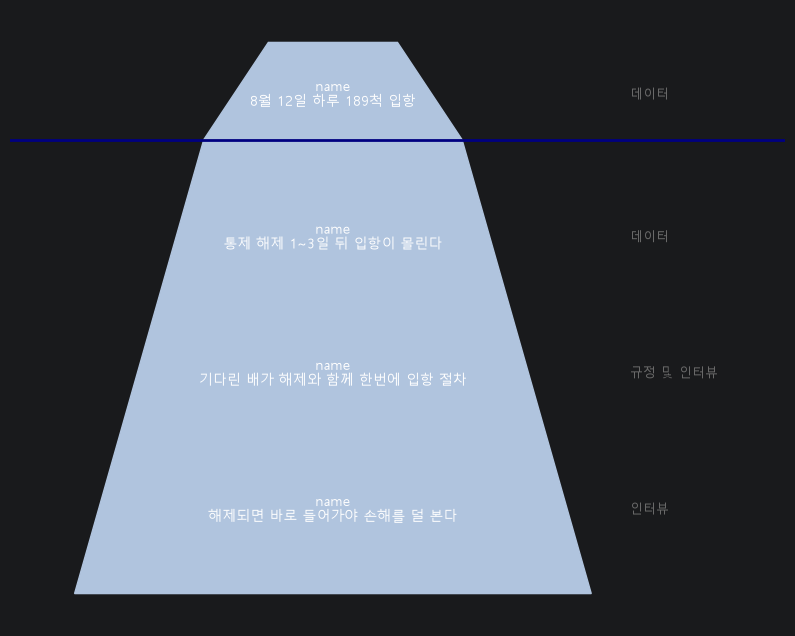

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

layers = [
    ('사건', '8월 12일 하루 189척 입항', '데이터'),
    ('패턴','통제 해제 1~3일 뒤 입항이 몰린다', '데이터'),
    ('구조','기다린 배가 해제와 함께 한번에 입항 절차','규정 및 인터뷰'),
    ('생각','해제되면 바로 들어가야 손해를 덜 본다','인터뷰')
]

fig, ax = plt.subplots(figsize=(10, 8))
ax.add_patch(
    Polygon(
        [[4,9],[3,7.5],[1,0.5],[9,0.5],[7,7.5],[6,9]],
        closed=True,
        color = 'lightsteelblue',
    )
)

ax.axhline(7.5, color= 'navy', linewidth=2)
label_y = [8.2,6.0,3.9,1.8]

for (name, example, source), y in zip(layers, label_y):
    ax.text(5, y, f'name\n{example}', ha='center', va='center', fontsize=10)
    ax.text(9.6,y,source, va='center', fontsize=9, color='dimgray')

ax.set_xlim(0,12)
ax.set_ylim(0, 9.5)

ax.axis('off')

plt.show()


# 문제나무 problem tree
문제나무는 가운데 줄기 부분에 핵심 문제를 두고서 아래 뿌리에 원인을 위 가지에 결과(영향)을 그리는 그림이다.

문제나무는 원인과 결과를 한 장에 위치시킨 다음에 왜 이 문제를 풀어야 하는가 까지 보여줄 수 있다.

원인기ㅘ 결과를 뒤집는 실수를 종종 할 수 있다. 관제 업무가 몰린다 <-원인이 아니라 결과이다. A 때문에 B가 생긴다라고 먼저 문장을 만들고 자연스러운 쪽으로 화살표를 그려본다

"""text
터미널 통제 상황이 해제된 다음에 입항이 몰린다.

<원인>
- 태풍으로 인한 통제 상황
- 배가 몰려 대기하던 배가 한번에 입항 허가
- 도착 순서를 관리하는 시스템이 부재/미비

<결과>
- 관제 업무 과도 집중
- 예선/도선 대기
- 터미널 하역 몰림

같은 상황을 두고 문제를 어느 높이에 작성하느야에 따라서 할 수 있는 일이 달라진다.

- 부산항의 경쟁력을 높여야 한다.
- 관제 관련 대시보드에 입항 대기 알림을 띄워야 한다.

추상화 사다리leader of abstraction는 문제를 사다리칸처럼 위 아래로 옮겨보면서 알맞는 높이를 찾아가는 도구를 의미한다.

사다리 안에서 문제를 옮기는 기준은 현재 옮기고자 하는 문제에서 왜(넓은 목적)를 물어보는 질문이면 위칸으로 옮기고 어떻게(구체적인 방법)을 물어보는 질문이면 아래칸으로 옮기는 방식으로 한다.

현재 옮기고 있는 해당 칸이 알맞는 위치이구나 하는 판단은 일반적으로 다음의 조건을 만족하는 칸일 가능성이 높다.

- 숫자로 잴 수 있는 지표가 있어야 한다.
- 해결책이 아직 정해지지 않아서 방법을 비교할 여지가 있어야 한다.

### 목표
- 부산항의 경쟁력을 높이기
- 기상 통제 뒤에도 항만 운영이 고르게 돌아가게 하기
- 관제 화면에 입항 예약 알림 띄우기
- 통제 해제 뒤 입항이 하루에 몰리지 않게 하기
- 통제 해제 뒤 입하 순서를 예약으로 나누기
- 관제 화면에 입항 예약 알림 띄우기


## 문제정의
문제 정의problem definition를 정리해보면 누가 어떤 상황에서 무엇 때문에 곤란을 겪고 그 결과 무엇을 잃는가를 해결챌과 분리해서 명확한 문장으로 정리하는 일이다.

건축물을 건설하기 전에는 설계도를 그린다. 이것처럼 서비스를 만들기 전에는 풀어야 할 문제를 먼저 고정해두는 것이 바람직한 서비스를 만들 수 있는 방법이 될 수 있다.

현장에서 나올 수 있는 요청사항들을 다음과 같이 구분할 수 있다.
- 요청request: 이해관계자가 원하는 것을 그대로 말한 것/
- 증상symptom: 겉으로 드러나서 누구나 느끼고 있는 불편
- 원인: cause: 증상을 만들어내는 이유
- 해결책 solution: 원인을 없애거나 줄이는 방법

요청과 증상은 무엇을 만들가에 대한 답이 될 수 있고 원인과 해결책은 무엇이 잘못되었나에 대한 답이 될 수 있다

문제 정의는 뒤쪽 두가지 원인과 해결책에 집중해 볼 수 있다.

## 증상/원인/해결책 구분 방법
증상/원인/해결책을 구분하는 가장 간단한 방법은 각각의 의견에 '그래서 뭐가 불편한거지?''왜 그런거지?'질문을 붙여본다.

- 선석 예약 앱을 만들자
    - 뭐가 불편해서 그런거지? -> 기다리는 시간이 길다.
        - 왜 기다리는 시간이 긴거지? -> 특정 시간대에 몰리는 구나.

문장으로 정리해 두어야 한다. 이후에 기획을 구체화할 때 한번에 재검토를 해봐야 한다.

해결책이 문제처럼 위장해서 나오는 경우가 더러 있다. ' 스마트 선석 시스템이 없다'와 같이 문제처럼 보이는 문장이 나오는데 실제로는 '시스템을 도입하자'를 뒤집어서 말한 해결책이다.

해결책을 암시하는 단어들 만들자, 도입하자, 앱, 시스템이 나오면 우선 해결책으로 구분한 다음에 다른 문제를 찾는 것도 방법이 될 수 있다.

- 선서 운항담당자: 아침에 입항하면 선석이 비기를 몇 시간씩 기다려요. / 증상
- 터미널 선석 플래너: 선박 도착 예정 시각이 자주 바뀌어서 선석 계획을 다시 짭니다. / 원인
- 항만공사 운영팀: 선석 예약앱을 만들면 좋겠습니다. / 해결책 -- > 여기까지 묶임
- 수입담당 포워더: 컨테이너를 언제 찾아갈 수 있는지 미리 알 수가 없어요. / 증상
- 관제 담당자: 오전 6-9시에 입항이 밀려요. /원인
- 선사 운영 담당자: AI 스케줄링 시스템을 도입했으면 좋겠습니다. /해결책 -> 위의 꺼 해결

## 문제 정의문 problem statement
증상과 원인을 모았다면 문장으로 정리해야 한다. 문제 정의문이라고 일컫는다. 문제 정의문도 적는 방법 같은 것들이 있다.

[사용자]는 [상황]에서 [겪는 일]을 겪는다.
그 결과 [영향]이 생긴다.
이 문제의 크기는 [측정 지표]로 잴 수 있다.